In [1]:
%matplotlib inline
import os, gc, sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

In [2]:
# ──────────────────────────── config ────────────────────────────
BASE_MODEL  = "facebook/mbart-large-50-many-to-many-mmt"
ADAPTER_DIR = "./final_mbart_lora_v2"
MAX_LEN     = 64
BATCH_SIZE  = 8
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR     = "."          # where .npy and .png land
# ────────────────────────────────────────────────────────────────

In [3]:
def load_parallel(sa_path, en_path):
    """Load aligned Sanskrit / English CSV pair."""
    sa = pd.read_csv(sa_path, encoding="utf-8", engine="python", quotechar='"')
    en = pd.read_csv(en_path, encoding="utf-8", engine="python", quotechar='"')
    sa_col = [c for c in sa.columns if "Sentence" in c][0]
    en_col = [c for c in en.columns if "Sentence" in c][0]
    df = pd.DataFrame({
        "source_id": sa["Source_id"],
        "sanskrit":  sa[sa_col].astype(str).str.strip(),
        "english":   en[en_col].astype(str).str.strip(),
    })
    df = df[(df["sanskrit"] != "") & (df["english"] != "")]
    return df.reset_index(drop=True)

In [4]:
# ── 1. Load data ─────────────────────────────────────────────────
print("Loading data …")
test_df = load_parallel("test_demo_sa - Sheet1 - test_demo_sa - Sheet1.csv","test_demo_en - Sheet1 - test_demo_en - Sheet1.csv")
dev_df  = load_parallel("dev_sa_1000.csv",  "dev_en_1000.csv")
print(f"  test: {len(test_df)}   dev: {len(dev_df)}")

Loading data …
  test: 100   dev: 1000


In [5]:
# ── 2. Load model ────────────────────────────────────────────────
print("Loading mBART-50 base model …")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL, torch_dtype=torch.float16)

print("Loading LoRA adapter …")
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model = model.to(DEVICE).eval()
print(f"  Model on {DEVICE}")

Loading mBART-50 base model …


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Loading LoRA adapter …
  Model on cuda


In [6]:
# ── 3. Embedding function ────────────────────────────────────────
@torch.no_grad()
def get_embeddings(texts, batch_size=BATCH_SIZE):
    """Mean-pool encoder hidden states → (N, D) float32 numpy array."""
    base = model.base_model.model if hasattr(model, "base_model") else model
    encoder = base.get_encoder()
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inp = tokenizer(
            batch, return_tensors="pt",
            padding=True, truncation=True, max_length=MAX_LEN,
        ).to(DEVICE)
        out  = encoder(input_ids=inp.input_ids, attention_mask=inp.attention_mask)
        mask = inp.attention_mask.unsqueeze(-1).float()
        emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        embs.append(emb.cpu().float().numpy())
        torch.cuda.empty_cache()
    return np.vstack(embs)

In [7]:
# ── 4. Generate & save test embeddings ────────────────────────────
print("Generating Sanskrit test embeddings …")
sa_emb = get_embeddings(test_df["sanskrit"].tolist())

print("Generating English test embeddings …")
en_emb = get_embeddings(test_df["english"].tolist())

sa_path = os.path.join(OUT_DIR, "sa_embeddings.npy")
en_path = os.path.join(OUT_DIR, "en_embeddings.npy")
np.save(sa_path, sa_emb)
np.save(en_path, en_emb)
print(f"  Saved  sa_embeddings.npy  shape={sa_emb.shape}")
print(f"  Saved  en_embeddings.npy  shape={en_emb.shape}")

Generating Sanskrit test embeddings …
Generating English test embeddings …
  Saved  sa_embeddings.npy  shape=(100, 1024)
  Saved  en_embeddings.npy  shape=(100, 1024)


In [8]:
# ── 5. Cosine similarity evaluation ──────────────────────────────
def eval_cosine(sa_vecs, en_vecs, label=""):
    """Row-wise cosine similarity statistics."""
    # row-wise cosine = dot / (norm * norm)
    cos = np.array([
        cosine_similarity(sa_vecs[i:i+1], en_vecs[i:i+1])[0, 0]
        for i in range(len(sa_vecs))
    ])
    print(f"\n  [{label}] Cosine similarity (paired SA↔EN)")
    print(f"    mean   = {cos.mean():.4f}")
    print(f"    median = {np.median(cos):.4f}")
    print(f"    std    = {cos.std():.4f}")
    print(f"    min    = {cos.min():.4f}   max = {cos.max():.4f}")
    return cos

print("── Cosine Similarity (Test set) ─────────────")
test_cos = eval_cosine(sa_emb, en_emb, label="TEST")

print("\nGenerating Dev embeddings for cosine eval …")
dev_sa_emb = get_embeddings(dev_df["sanskrit"].tolist())
dev_en_emb = get_embeddings(dev_df["english"].tolist())

print("\n── Cosine Similarity (Dev set) ──────────────")
dev_cos = eval_cosine(dev_sa_emb, dev_en_emb, label="DEV")

── Cosine Similarity (Test set) ─────────────

  [TEST] Cosine similarity (paired SA↔EN)
    mean   = 0.4766
    median = 0.4697
    std    = 0.1190
    min    = 0.2293   max = 0.8000

Generating Dev embeddings for cosine eval …

── Cosine Similarity (Dev set) ──────────────

  [DEV] Cosine similarity (paired SA↔EN)
    mean   = 0.4812
    median = 0.4781
    std    = 0.1310
    min    = 0.1331   max = 1.0000


Running t-SNE on 100 sample pairs …


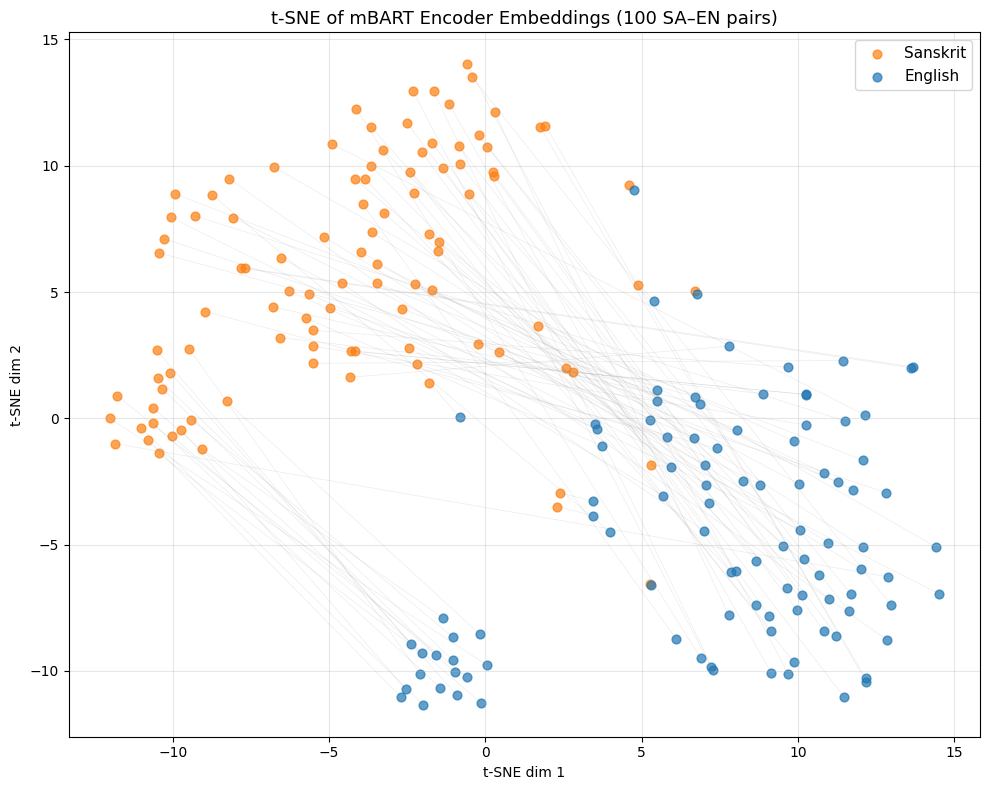

  Saved tsne_visualization.png


In [9]:
# ── 6. t-SNE Visualization (100 sample pairs) ────────────────────
print("Running t-SNE on 100 sample pairs …")
N_VIS = 100
sa_vis = sa_emb[:N_VIS]
en_vis = en_emb[:N_VIS]

combined = np.vstack([sa_vis, en_vis])           # (200, D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
proj = tsne.fit_transform(combined)

sa_proj = proj[:N_VIS]
en_proj = proj[N_VIS:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(sa_proj[:, 0], sa_proj[:, 1], c="tab:orange", label="Sanskrit", alpha=0.7, s=40)
ax.scatter(en_proj[:, 0], en_proj[:, 1], c="tab:blue",   label="English",  alpha=0.7, s=40)

# draw light lines connecting each pair
for i in range(N_VIS):
    ax.plot([sa_proj[i, 0], en_proj[i, 0]],
            [sa_proj[i, 1], en_proj[i, 1]],
            c="gray", alpha=0.15, linewidth=0.5)

ax.set_title("t-SNE of mBART Encoder Embeddings (100 SA–EN pairs)", fontsize=13)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "tsne_visualization.png"), dpi=150)
plt.show()
print("  Saved tsne_visualization.png")

In [10]:
# ── Done ──────────────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
print("\n✓ All done!")


✓ All done!
